In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [2]:
df = pd.read_csv("loan_sanction_train.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


**Dataset:**  Home Loan Approval (Aprobacion de Prestamos para Casas)
**Descripción:**  
**Periodo:**  2023

|Columna/Variable|Descripción|Tipo_de_Variable|Importancia inicial|Nota|
|-|-|-|-|-|
|Loan_ID|Numero de Identificacion unico para los prestamos de cada cliente|Indice Unico|-|Identificador unico, util para encontrar outliers o missing data|
|Gender|Genero del cliente, masculino o femenino|Categorica|2|Demografica|
|Married|Estado civil del cliente, Casado o Soltero|Categorica|2|Demografica|
|Dependents|Numero de personas dependientes del cliente|Numerica Categorica|1|Demografica|
|Education|Nivel de educacion del cliente|Categorica|1|Demografica|
|Self_Employed|Si el cliente trabaja por cuenta propia o no|Categorica|1|Demografica|
|ApplicantIncome|Ingresos del cliente|Numerica Categorica|0|Indica el poder adquisitivo y potencial de prestamo del cliente|
|CoapplicantIncome|Ingresos de coaplicante del cliente, puede ser de la pareja, familia, etc.|Numerica Categorica|1|Indica el poder adquisitivo condicional del cliente|
|LoanAmount|Monto a prestar al cliente (en miles)|Numerica Categorica|0|Indica el monto a prestar al cliente de parte del banco|
|Loan_Amount_Term|Tiempo para pagar el prestamo (en meses)|Numerica Categorica|1|Indica el tiempo en que se pagara el prestamo|
|Credit_History|Historial de credito del cliente|Numerica Categorica|0|Si el historial de credito del cliente esta en regla|
|Property_Area|Donde se ubica la casa sujeta al prestamo|Categorica|0|Ubicacion de la casa relevante al prestamo|
|Loan_Status|Si el prestamo es aprobado o no|Categorica|0|Resolucion del prestamo|

In [4]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


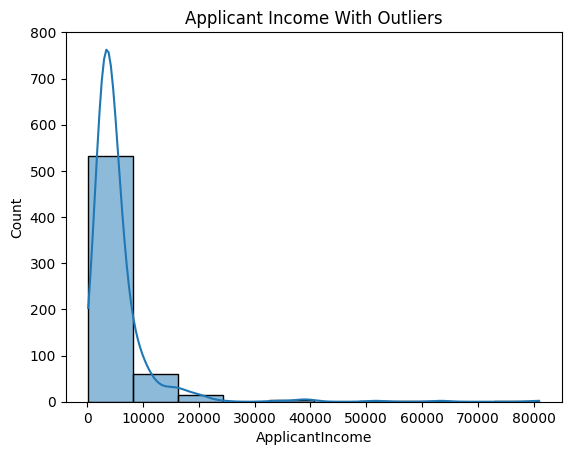

In [6]:
sns.histplot(df["ApplicantIncome"], bins=10,kde=True)
plt.title("Applicant Income With Outliers")
plt.show()

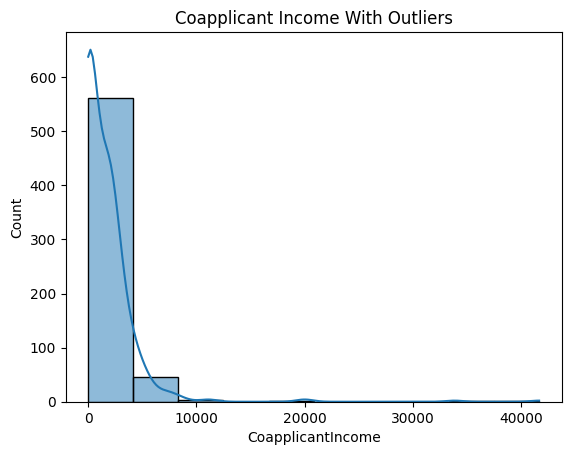

In [7]:
sns.histplot(df["CoapplicantIncome"], bins=10,kde=True)
plt.title("Coapplicant Income With Outliers")
plt.show()

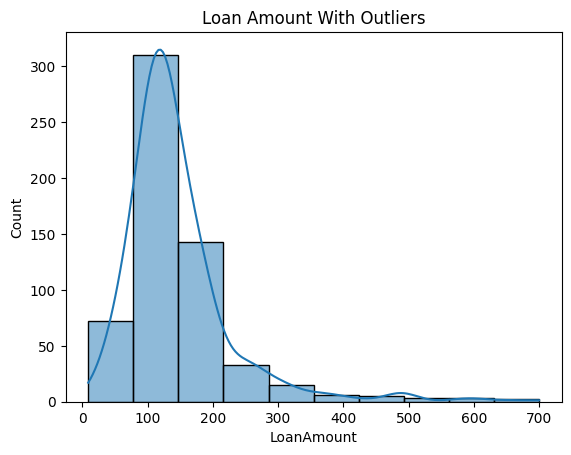

In [8]:
sns.histplot(df["LoanAmount"], bins=10,kde=True)
plt.title("Loan Amount With Outliers")
plt.show()

In [9]:
# Hay outliers muy evidentes en las columnas de ApplicantIncome, CoapplicantIncome y LoanAmount, por lo que esos
# outliers se pueden descartar para no arruinar el modelo, pero se guardaran aparte en caso de que puedan ser utiles luego.
df = df[df["ApplicantIncome"] < 20000]
df = df[df["CoapplicantIncome"] < 10000]
df = df[df["LoanAmount"] < 500]
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,572.000000,572.000000,572.000000,558.000000,526.000000
mean,4694.486014,1430.041818,137.618881,342.365591,0.844106
std,2976.245976,1678.618421,64.036233,65.183589,0.363100
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2880.500000,0.000000,100.000000,360.000000,1.000000
50%,3750.000000,1239.500000,126.000000,360.000000,1.000000
75%,5588.250000,2259.250000,161.000000,360.000000,1.000000
max,18165.000000,8980.000000,496.000000,480.000000,1.000000


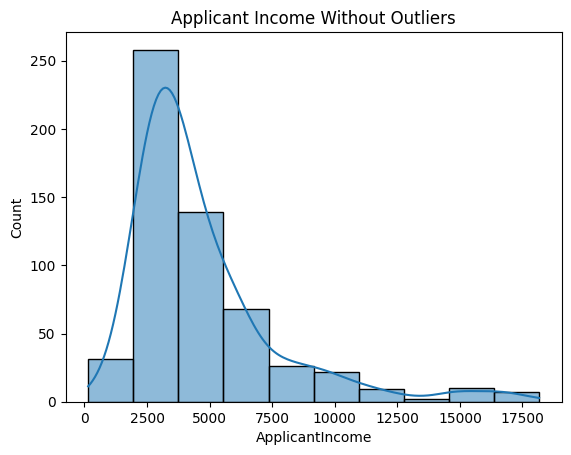

In [10]:
sns.histplot(df["ApplicantIncome"], bins=10,kde=True)
plt.title("Applicant Income Without Outliers")
plt.show()

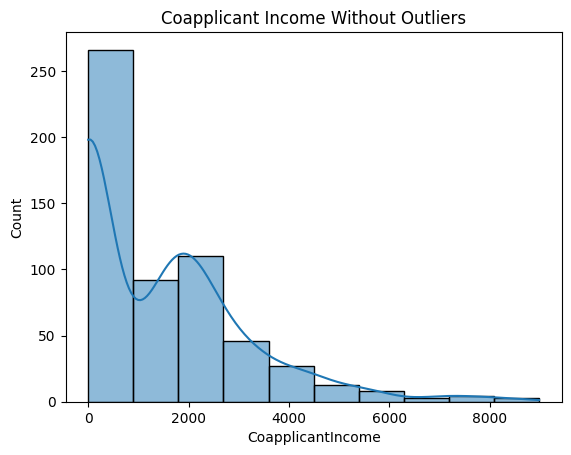

In [11]:
sns.histplot(df["CoapplicantIncome"], bins=10,kde=True)
plt.title("Coapplicant Income Without Outliers")
plt.show()

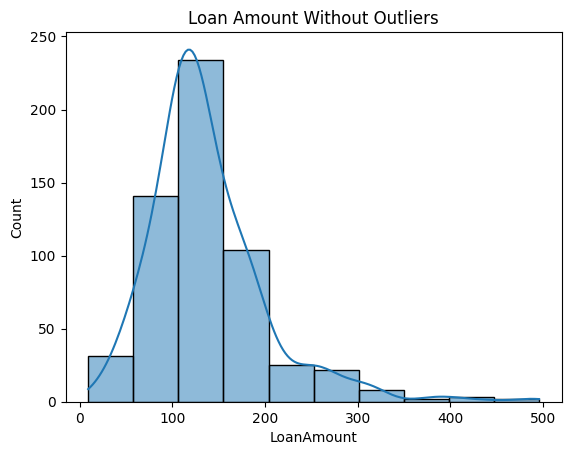

In [12]:
sns.histplot(df["LoanAmount"], bins=10,kde=True)
plt.title("Loan Amount Without Outliers")
plt.show()

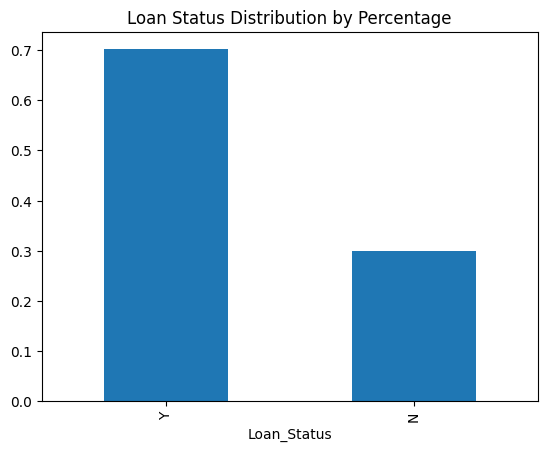

In [13]:
df["Loan_Status"].value_counts(normalize=True).plot(kind="bar")
plt.title("Loan Status Distribution by Percentage")
plt.show()

In [14]:
# Realizaremos el train/test split ahora para evitar Data Leakage y asi el test set no se vea afectado por
# los valores presentes en el train set, pero despues de eliminar los outliers para no necesitar realizarlo dos veces.
from sklearn.model_selection import train_test_split
dftr, dftst = train_test_split(df, test_size=0.20, random_state=117)
print(dftr.shape)
print(dftst.shape)

(457, 13)
(115, 13)


Married
Yes    0.643326
No     0.354486
NaN    0.002188
Name: proportion, dtype: float64
  Loan_Status Married  proportion
0           N     Yes    0.570312
1           N      No    0.429688
2           Y     Yes    0.673780
3           Y      No    0.326220


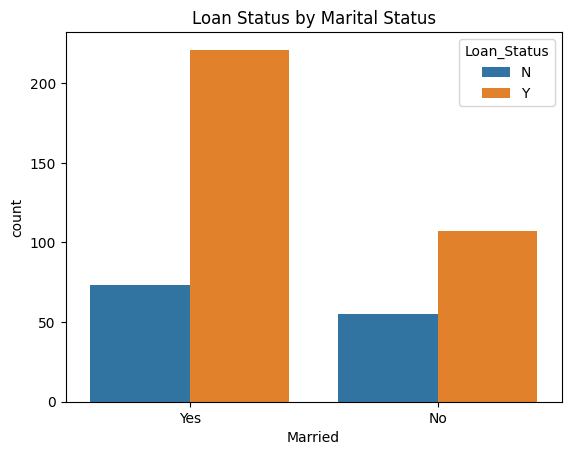

In [15]:
loanstat = dftr.groupby("Loan_Status")
ApprovalByMarriage = loanstat["Married"].value_counts(normalize=True).reset_index()
print(dftr["Married"].value_counts(normalize=True, dropna=False))
print(ApprovalByMarriage)
sns.countplot(x="Married", stat="count", hue="Loan_Status", data=dftr)
plt.title("Loan Status by Marital Status")
plt.show()

In [16]:
# Debido a que solo hay 3 filas con valor nulo en esta columna y se muestra que hay un resultado negativo a los No Casados
# pero debido a que solo hay 3 filas con valor nulo se asignara el valor mas cercano a los datos nulos.
dftr["Married"].fillna(method="pad", inplace=True)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1264368556.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftr["Married"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1264368556.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dftr["Married"].fillna(method="pad", inplace=True)


Gender
Male      0.787746
Female    0.192560
NaN       0.019694
Name: proportion, dtype: float64
  Loan_Status  Gender  proportion
0           N    Male    0.806452
1           N  Female    0.193548
2           Y    Male    0.802469
3           Y  Female    0.197531


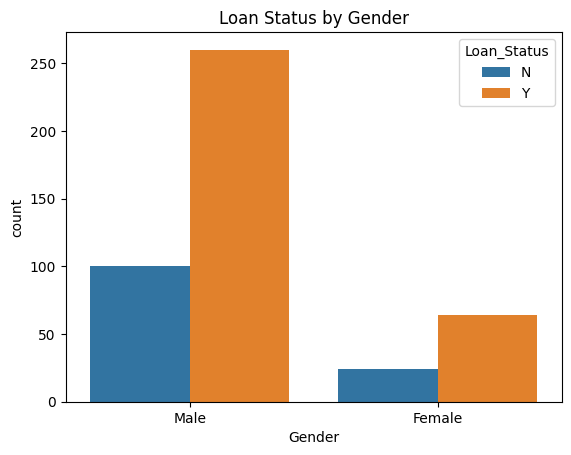

In [17]:
ApprovalByGender = loanstat["Gender"].value_counts(normalize=True).reset_index()
print(dftr["Gender"].value_counts(normalize=True, dropna=False))
print(ApprovalByGender)
sns.countplot(x = "Gender", hue = "Loan_Status", data = dftr)
plt.title("Loan Status by Gender")
plt.show()

In [18]:
# Se nota que el genero no tiene mucho valor en la prediccion, por lo que se puede rellenar con valores aleatorios
dftr["Gender"].fillna(method="pad", inplace=True)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1647839493.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftr["Gender"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1647839493.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dftr["Gender"].fillna(method="pad", inplace=True)


Education
Graduate        0.772429
Not Graduate    0.227571
Name: proportion, dtype: float64
  Loan_Status     Education  proportion
0           N      Graduate    0.703125
1           N  Not Graduate    0.296875
2           Y      Graduate    0.799392
3           Y  Not Graduate    0.200608


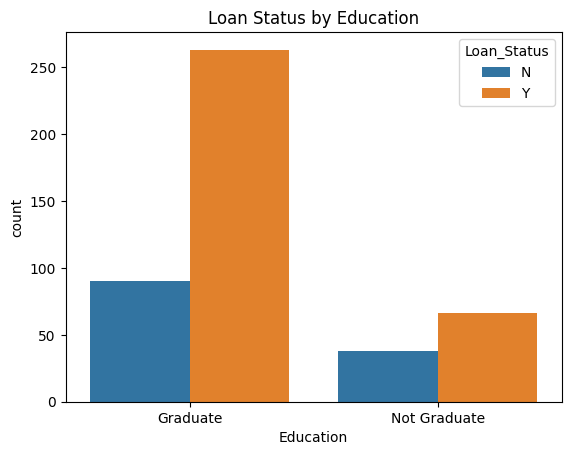

In [19]:
ApprovalByEducation = loanstat["Education"].value_counts(normalize=True).reset_index()
print(dftr["Education"].value_counts(normalize=True))
print(ApprovalByEducation)
sns.countplot(x="Education", hue="Loan_Status", data=dftr)
plt.title("Loan Status by Education")
plt.show()

In [20]:
dftr["Education"].value_counts(normalize=True, dropna=False)

Education
Graduate        0.772429
Not Graduate    0.227571
Name: proportion, dtype: float64

Property_Area
Semiurban    0.378556
Urban        0.312910
Rural        0.308534
Name: proportion, dtype: float64
  Loan_Status Property_Area  proportion
0           N         Rural    0.398438
1           N         Urban    0.328125
2           N     Semiurban    0.273438
3           Y     Semiurban    0.419453
4           Y         Urban    0.306991
5           Y         Rural    0.273556


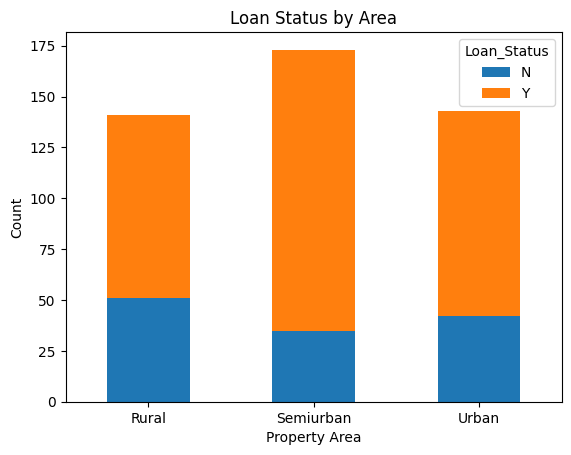

In [21]:
ApprovalByArea = loanstat["Property_Area"].value_counts(normalize=True).reset_index()
ApprovalByAreaPlot = dftr.groupby("Property_Area")["Loan_Status"].value_counts().unstack()
print(dftr["Property_Area"].value_counts(normalize=True))
print(ApprovalByArea)
ApprovalByAreaPlot.plot(kind="bar", stacked=True)
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.title("Loan Status by Area")
plt.xticks(rotation=0)
plt.show()

Dependents
0      0.557987
2      0.175055
1      0.161926
3+     0.080963
NaN    0.024070
Name: proportion, dtype: float64
  Loan_Status Dependents  proportion
0           N          0    0.617886
1           N          1    0.211382
2           N          2    0.089431
3           N         3+    0.081301
4           Y          0    0.554180
5           Y          2    0.213622
6           Y          1    0.148607
7           Y         3+    0.083591


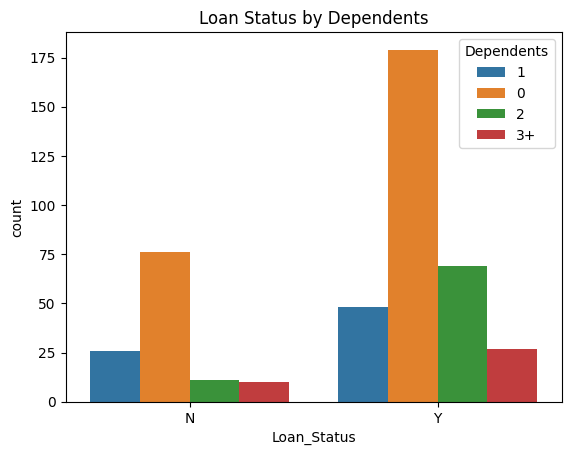

In [22]:
ApprovalByDependents = loanstat["Dependents"].value_counts(normalize=True).reset_index()
print(dftr["Dependents"].value_counts(normalize=True, dropna=False))
print(ApprovalByDependents)
sns.countplot(x="Loan_Status", hue="Dependents", data=dftr)
plt.title("Loan Status by Dependents")
plt.show()

In [23]:
# Solo se aprecia una relacion significativa entre el numero de dependientes y la aprobacion de prestamos cuando el numero
# de dependientes es 0, por lo que se pueden rellenar los datos faltantes con valores proximos.
dftr["Dependents"].fillna(method="pad", inplace=True)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\2799208014.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftr["Dependents"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\2799208014.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dftr["Dependents"].fillna(method="pad", inplace=True)


Self_Employed
No     0.803063
Yes    0.140044
NaN    0.056893
Name: proportion, dtype: float64
  Loan_Status Self_Employed  proportion
0           N            No    0.860656
1           N           Yes    0.139344
2           Y            No    0.847896
3           Y           Yes    0.152104


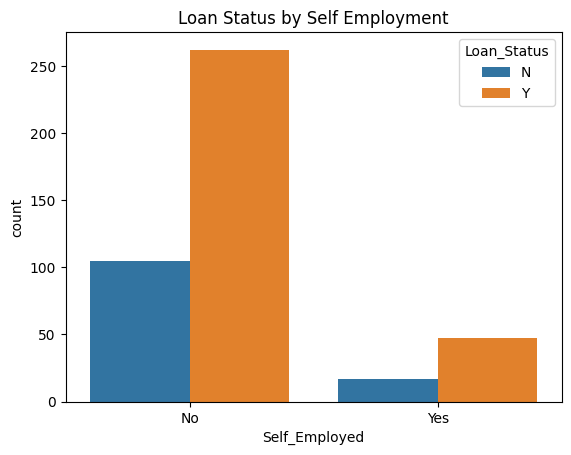

In [24]:
ApprovalByEmployment = loanstat["Self_Employed"].value_counts(normalize=True).reset_index()
print(dftr["Self_Employed"].value_counts(normalize=True, dropna=False))
print(ApprovalByEmployment)
sns.countplot(x="Self_Employed", hue="Loan_Status", data=dftr)
plt.title("Loan Status by Self Employment")
plt.show()

In [25]:
# No se aprecia relacion significativa entre el empleo por cuenta propia y la aprobacion de prestamos, 
# excepto cuando el numero de dependientes es 0, por lo que se pueden rellenar los datos faltantes con valores proximos.
dftr["Self_Employed"].fillna(method="pad", inplace=True)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1877025290.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftr["Self_Employed"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1877025290.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  dftr["Self_Employed"].fillna(method="pad", inplace=True)


Credit_History
1.0    0.789934
0.0    0.122538
NaN    0.087527
Name: proportion, dtype: float64
  Loan_Status  Credit_History  proportion
0           N             1.0    0.567797
1           N             0.0    0.432203
2           Y             1.0    0.983278
3           Y             0.0    0.016722


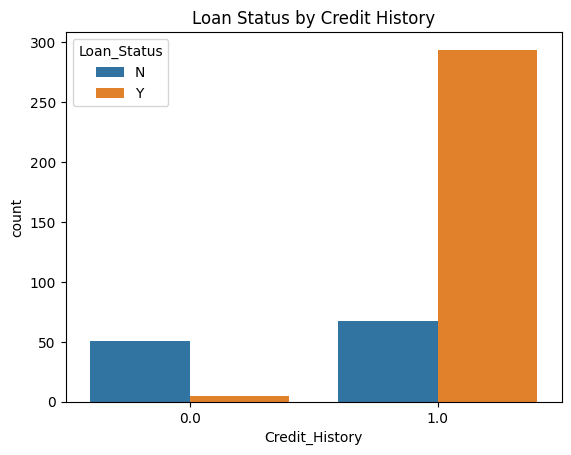

In [26]:
ApprovalByCreditHistory = loanstat["Credit_History"].value_counts(normalize=True).reset_index()
print(dftr["Credit_History"].value_counts(normalize=True, dropna=False))
print(ApprovalByCreditHistory)
sns.countplot(x="Credit_History", hue="Loan_Status", data=dftr)
plt.title("Loan Status by Credit History")
plt.show()

In [27]:
# Credit_History tiene una gran importancia e influencia en la aprobacion del prestamo, por lo cual no se puede rellenar con valores aleatorios
# asi que se rellenaran como valores positivos, y asi tener mas datos negativos cuando el Credit History es positivo.
dftr["Credit_History"].fillna(dftr["Credit_History"].mode()[0], inplace=True)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\474331201.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftr["Credit_History"].fillna(dftr["Credit_History"].mode()[0], inplace=True)


Loan_Amount_Term
360.0    0.840263
180.0    0.074398
480.0    0.021882
NaN      0.017505
300.0    0.017505
240.0    0.006565
120.0    0.006565
84.0     0.006565
60.0     0.004376
36.0     0.002188
12.0     0.002188
Name: proportion, dtype: float64
Loan_Status  Loan_Amount_Term
N            360.0               0.814516
             180.0               0.088710
             480.0               0.048387
             300.0               0.024194
             36.0                0.008065
             84.0                0.008065
             240.0               0.008065
Y            360.0               0.870769
             180.0               0.070769
             300.0               0.015385
             480.0               0.012308
             120.0               0.009231
             60.0                0.006154
             84.0                0.006154
             240.0               0.006154
             12.0                0.003077
Name: proportion, dtype: float64


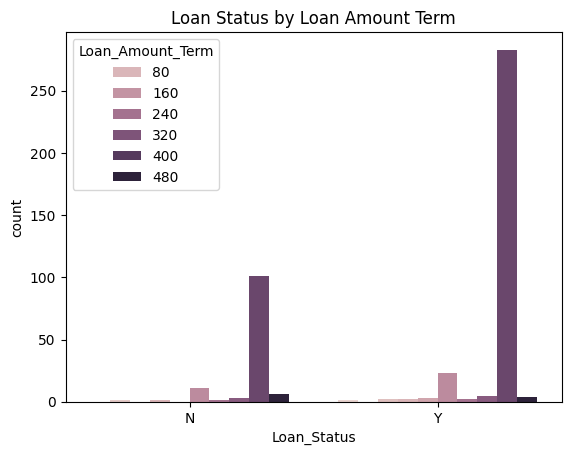

In [28]:
ApprovalByLoanTerm = loanstat["Loan_Amount_Term"].value_counts(normalize=True)
print(dftr["Loan_Amount_Term"].value_counts(normalize=True, dropna=False))
print(ApprovalByLoanTerm)
sns.countplot(x="Loan_Status", hue="Loan_Amount_Term", data=dftr)
plt.title("Loan Status by Loan Amount Term")
plt.show()

In [29]:
# Aunque hayan varios terminos de tiempo para los pagos, se puede usar el valor mas comun para
# rellenar los datos faltantes ya que no es de gran importancia en la prediccion del modelo.
dftr["Loan_Amount_Term"].fillna(dftr["Loan_Amount_Term"].mode()[0], inplace=True)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\1004011330.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dftr["Loan_Amount_Term"].fillna(dftr["Loan_Amount_Term"].mode()[0], inplace=True)


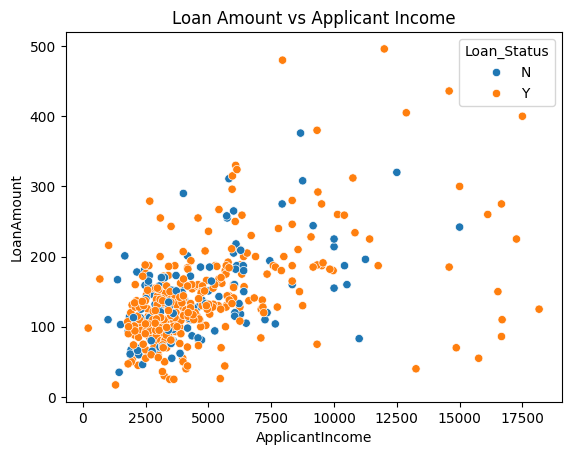

In [30]:
sns.scatterplot(x="ApplicantIncome", y="LoanAmount", hue="Loan_Status", data=dftr)
plt.title("Loan Amount vs Applicant Income")
plt.show()

In [31]:
# Loan Amount tiene una gran cantidad de datos unicos, asi que no se pueden rellenar con valores aleatorios o proximos, a pesar de
# se creia que tendria mucha mayor importancia a la que realmente tiene, por lo que le daran el valor de la media.
dftr.fillna(dftr["LoanAmount"].median(), inplace=True)

In [32]:
dftr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 457 entries, 1 to 530
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            457 non-null    object 
 1   Gender             457 non-null    object 
 2   Married            457 non-null    object 
 3   Dependents         457 non-null    object 
 4   Education          457 non-null    object 
 5   Self_Employed      457 non-null    object 
 6   ApplicantIncome    457 non-null    int64  
 7   CoapplicantIncome  457 non-null    float64
 8   LoanAmount         457 non-null    float64
 9   Loan_Amount_Term   457 non-null    float64
 10  Credit_History     457 non-null    float64
 11  Property_Area      457 non-null    object 
 12  Loan_Status        457 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 50.0+ KB


In [33]:
dftst.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115 entries, 160 to 48
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            115 non-null    object 
 1   Gender             113 non-null    object 
 2   Married            114 non-null    object 
 3   Dependents         113 non-null    object 
 4   Education          115 non-null    object 
 5   Self_Employed      112 non-null    object 
 6   ApplicantIncome    115 non-null    int64  
 7   CoapplicantIncome  115 non-null    float64
 8   LoanAmount         115 non-null    float64
 9   Loan_Amount_Term   109 non-null    float64
 10  Credit_History     109 non-null    float64
 11  Property_Area      115 non-null    object 
 12  Loan_Status        115 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 12.6+ KB


In [71]:
# Haremos una funcion para convertir todos los datos faltantes en el test set con los mismos parametros que en el train set.
# Tambien para usar mas adelante en caso de necesitar hacer splits diferentes mas adelante.
def splitfillna(df):
    df["Married"].fillna(method="pad", inplace=True)
    df["Gender"].fillna(method="pad", inplace=True)
    df["Education"].fillna(method="pad", inplace=True)
    df["Dependents"].fillna(method="pad", inplace=True)
    df["Self_Employed"].fillna(method="pad", inplace=True)
    df["Credit_History"].fillna(df["Credit_History"].mode()[0], inplace=True)
    df["Loan_Amount_Term"].fillna(df["Loan_Amount_Term"].mode()[0], inplace=True)
    df["LoanAmount"].fillna(df["LoanAmount"].median(), inplace=True)

splitfillna(dftst)
dftst.info()

<class 'pandas.core.frame.DataFrame'>
Index: 115 entries, 160 to 48
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            115 non-null    object 
 1   Gender             115 non-null    int64  
 2   Married            115 non-null    int64  
 3   Dependents         115 non-null    int64  
 4   Education          115 non-null    int64  
 5   Self_Employed      115 non-null    int64  
 6   ApplicantIncome    115 non-null    int64  
 7   CoapplicantIncome  115 non-null    float64
 8   LoanAmount         115 non-null    float64
 9   Loan_Amount_Term   115 non-null    float64
 10  Credit_History     115 non-null    float64
 11  Property_Area      115 non-null    int64  
 12  Loan_Status        115 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 12.6+ KB


C:\Users\artur\AppData\Local\Temp\ipykernel_21660\3232026574.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Married"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\3232026574.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Married"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\3232026574.py:5: FutureWarning: A value is trying to be set on a copy

In [40]:
dftr.describe()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
count,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000,457.000000
mean,0.796499,0.645514,0.774617,0.227571,0.150985,4787.877462,1489.424770,140.921225,341.225383,0.877462,1.004376,0.719912
std,0.403043,0.478881,1.017161,0.419724,0.358426,3016.620223,1750.293831,67.193475,65.626565,0.328266,0.789169,0.449534
min,0.000000,0.000000,0.000000,0.000000,0.000000,210.000000,0.000000,17.000000,12.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,2957.000000,0.000000,100.000000,360.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000,0.000000,0.000000,3812.000000,1287.000000,128.000000,360.000000,1.000000,1.000000,1.000000
75%,1.000000,1.000000,2.000000,0.000000,0.000000,5746.000000,2333.000000,168.000000,360.000000,1.000000,2.000000,1.000000
max,1.000000,1.000000,3.000000,1.000000,1.000000,18165.000000,8980.000000,496.000000,480.000000,1.000000,2.000000,1.000000


In [35]:
dftst.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,115.000000,115.000000,115.000000,109.000000,109.000000
mean,4323.356522,1194.059130,124.495652,348.440367,0.761468
std,2791.774111,1337.568552,47.559081,60.902690,0.428155
min,150.000000,0.000000,9.000000,36.000000,0.000000
25%,2610.000000,0.000000,97.000000,360.000000,1.000000
50%,3481.000000,913.000000,120.000000,360.000000,1.000000
75%,4838.500000,2126.500000,146.500000,360.000000,1.000000
max,16250.000000,5000.000000,304.000000,480.000000,1.000000


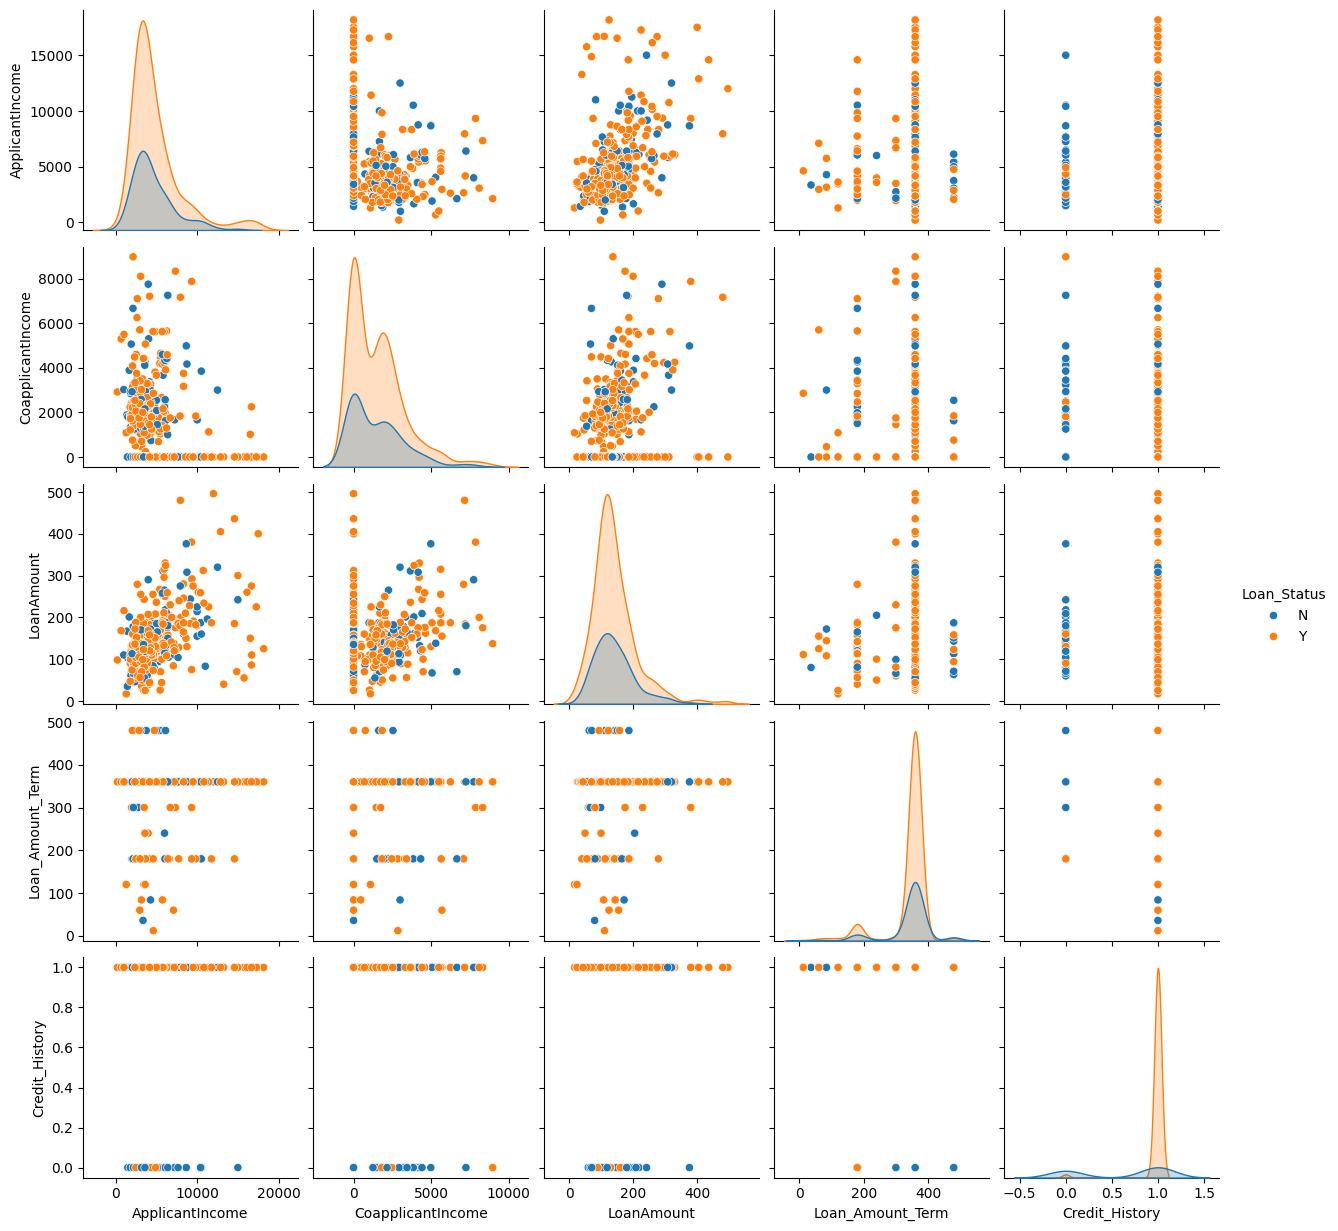

In [34]:
cols = ["ApplicantIncome","CoapplicantIncome","LoanAmount",
        "Loan_Amount_Term","Credit_History","Loan_Status"]
sns.pairplot(dftr[cols], hue="Loan_Status")
# plt.title("Analysis of Numerical Features by Loan Status")
# El titulo no se mostraba correctamente, por lo que se dejo como comentario.
plt.show()

In [ ]:
# Usaremos el LabelEncoder para convertir las variables categoricas a numericas
from sklearn import preprocessing
label_encoder = preprocessing.LabelEncoder()
dftr["Loan_Status"] = label_encoder.fit_transform(dftr["Loan_Status"])
dftr["Gender"] = label_encoder.fit_transform(dftr["Gender"])
dftr["Married"] = label_encoder.fit_transform(dftr["Married"])
dftr["Education"] = label_encoder.fit_transform(dftr["Education"])
dftr["Property_Area"] = label_encoder.fit_transform(dftr["Property_Area"])
dftr["Dependents"] = label_encoder.fit_transform(dftr["Dependents"])
# Dependents ya era Categorica Numerica, pero para 3 o mas dependientes tenia el valor "3+"
# por lo que se simplifica en esta operacion.
dftr["Self_Employed"] = label_encoder.fit_transform(dftr["Self_Employed"])
dftr

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
114,LP001398,1,0,0,0,0,5050,0.0,118.0,360.0,1.0,1,1
445,LP002429,1,1,1,0,1,3466,1210.0,130.0,360.0,1.0,0,1
335,LP002106,1,1,1,0,1,5503,4490.0,70.0,360.0,1.0,1,1
474,LP002524,1,0,2,0,0,5532,4648.0,162.0,360.0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
294,LP001947,1,1,0,0,0,2383,3334.0,172.0,360.0,1.0,1,1
361,LP002170,1,1,2,0,0,5000,3667.0,236.0,360.0,1.0,1,1
85,LP001279,1,0,0,0,0,2366,2531.0,136.0,360.0,1.0,1,1
121,LP001430,0,0,0,0,0,4166,0.0,44.0,360.0,1.0,1,1


In [58]:
# Haremos lo mismo con el test set tambien para categorizar correctamente, pero desde una funcion para poder usarlo
# mas adelante cuando se usen splits diferentes.
def splitlabelencoder(df):
    df["Loan_Status"] = label_encoder.fit_transform(df["Loan_Status"])
    df["Gender"] = label_encoder.fit_transform(df["Gender"])
    df["Married"] = label_encoder.fit_transform(df["Married"])
    df["Education"] = label_encoder.fit_transform(df["Education"])
    df["Property_Area"] = label_encoder.fit_transform(df["Property_Area"])
    df["Dependents"] = label_encoder.fit_transform(df["Dependents"])
    df["Self_Employed"] = label_encoder.fit_transform(df["Self_Employed"])

splitlabelencoder(dftst)
dftst

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
160,LP001560,1,1,0,1,0,1863,1041.0,98.0,360.0,1.0,1,1
240,LP001798,1,1,2,0,0,5819,5000.0,120.0,360.0,1.0,0,1
470,LP002515,1,1,1,0,1,3450,2079.0,162.0,360.0,1.0,1,1
110,LP001385,1,0,0,0,0,5316,0.0,136.0,360.0,1.0,2,1
275,LP001900,1,1,1,0,0,2750,1842.0,115.0,360.0,1.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
597,LP002943,1,0,0,0,0,2987,0.0,88.0,360.0,0.0,1,0
32,LP001097,1,0,1,0,1,4692,0.0,106.0,360.0,1.0,0,0
400,LP002288,1,1,2,1,0,2889,0.0,45.0,180.0,0.0,2,0
548,LP002776,0,0,0,0,0,5000,0.0,103.0,360.0,0.0,1,0


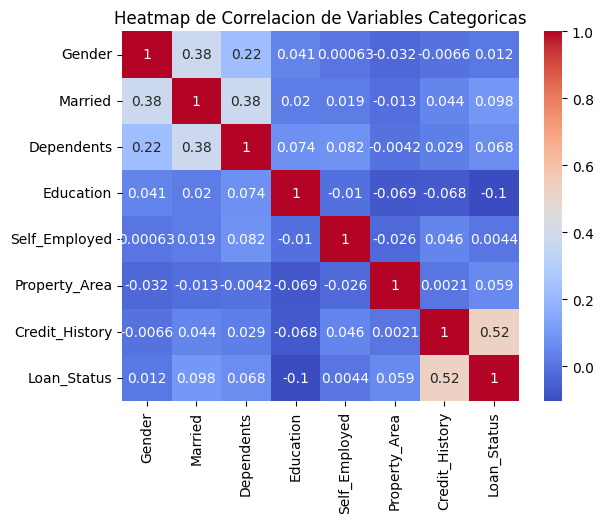

In [37]:
dftr_categorico = dftr[["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area", "Credit_History", "Loan_Status"]]
matrix_categorico = dftr_categorico.corr()
sns.heatmap(matrix_categorico, annot=True, cmap="coolwarm")
plt.title("Heatmap de Correlacion de Variables Categoricas")
plt.show()

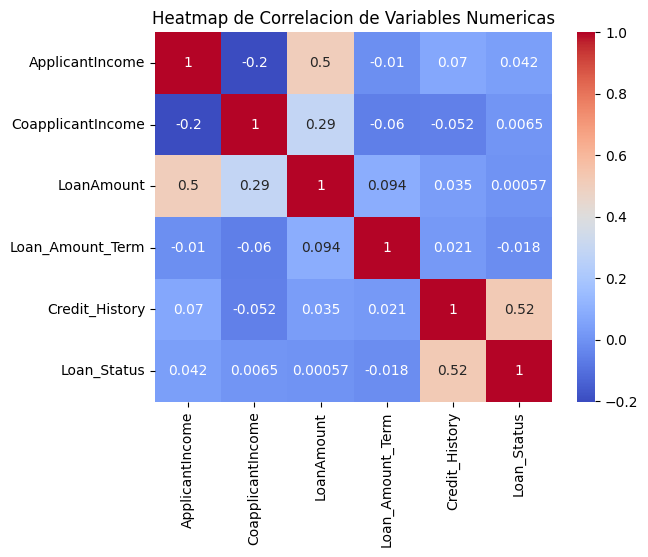

In [38]:
dftr_numerico = dftr.drop(["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area", "Loan_ID"], axis=1)
matrix_numerico = dftr_numerico.corr()
sns.heatmap(matrix_numerico, annot=True, cmap="coolwarm")
plt.title("Heatmap de Correlacion de Variables Numericas")
plt.show()

In [42]:
X_train = dftr.drop(["Loan_Status", "Loan_ID"], axis=1)
X_test = dftst.drop(["Loan_Status", "Loan_ID"], axis=1)
# Por ahora, usaremos todas las columnas para el primer modelo y usaremos menos de acuerdo a como se ajuste el modelo.
Y_train = dftr["Loan_Status"]
Y_test = dftst["Loan_Status"]

In [43]:
# Usaremos el StandardScaler para estandarizar las variables numericas.
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xstd_train = scaler.fit_transform(X_train)
Xstd_test = scaler.transform(X_test)
Ystd_train = Y_train
Ystd_test = Y_test
# Se añaden los Ystd_train y Ystd_test aunque no cambien solo para mantener consistencia en el uso cuando
# se necesite usar valores estandarizados en un modelo.

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier


In [45]:
def modelperformance(prediccion):
    print("Accuracy del modelo: {}".format(accuracy_score(Y_test, prediccion)))
    print("Report del modelo: \n{}".format(classification_report(Y_test, prediccion)))
    print("Confusion Matrix del modelo: \n{}".format(confusion_matrix(Y_test, prediccion)))
def modelperformancestd(prediccion):
    print("Accuracy del modelo: {}".format(accuracy_score(Ystd_test, prediccion)))
    print("Report del modelo: \n{}".format(classification_report(Ystd_test, prediccion)))
    print("Confusion Matrix del modelo: \n{}".format(confusion_matrix(Ystd_test, prediccion)))

In [46]:
logreg = LogisticRegression(max_iter=1000)
logreg.fit(Xstd_train, Ystd_train)
predicciones_logreg = logreg.predict(Xstd_test)
modelperformancestd(predicciones_logreg)

Accuracy del modelo: 0.8347826086956521
Report del modelo: 
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        43
           1       0.80      0.99      0.88        72

    accuracy                           0.83       115
   macro avg       0.88      0.78      0.80       115
weighted avg       0.86      0.83      0.82       115

Confusion Matrix del modelo: 
[[25 18]
 [ 1 71]]


In [47]:
grid_params = {"n_neighbors": [3,5,7,4,6,8,9,10,11,12,13,14,15],
               "weights": ["uniform", "distance"]}
KNC = GridSearchCV(KNeighborsClassifier(), grid_params)
KNC.fit(X_train, Y_train)
KNC.best_params_

{'n_neighbors': 14, 'weights': 'uniform'}

In [48]:
predicciones_knc = KNC.predict(X_test)
modelperformancestd(predicciones_knc)

Accuracy del modelo: 0.6347826086956522
Report del modelo: 
              precision    recall  f1-score   support

           0       0.55      0.14      0.22        43
           1       0.64      0.93      0.76        72

    accuracy                           0.63       115
   macro avg       0.59      0.54      0.49       115
weighted avg       0.61      0.63      0.56       115

Confusion Matrix del modelo: 
[[ 6 37]
 [ 5 67]]


In [49]:
svm = SVC()
svc_params = {"C": [0.25, 0.1, 0.2, 0.3, 0.5],
              "kernel":["linear","rbf","poly"]}
grid_svc = GridSearchCV(svm, svc_params)
grid_svc.fit(Xstd_train, Ystd_train)
grid_svc.best_params_

{'C': 0.25, 'kernel': 'linear'}

In [50]:
prediccion_svc = grid_svc.predict(Xstd_test)
modelperformancestd(prediccion_svc)

Accuracy del modelo: 0.8347826086956521
Report del modelo: 
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        43
           1       0.80      0.99      0.88        72

    accuracy                           0.83       115
   macro avg       0.88      0.78      0.80       115
weighted avg       0.86      0.83      0.82       115

Confusion Matrix del modelo: 
[[25 18]
 [ 1 71]]


In [51]:
# Usemos Random Forest a ver como va
rf = RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=117)
rf.fit(X_train, Y_train)
prediccion_rf = rf.predict(X_test)
modelperformance(prediccion_rf)

Accuracy del modelo: 0.8173913043478261
Report del modelo: 
              precision    recall  f1-score   support

           0       0.89      0.58      0.70        43
           1       0.79      0.96      0.87        72

    accuracy                           0.82       115
   macro avg       0.84      0.77      0.79       115
weighted avg       0.83      0.82      0.81       115

Confusion Matrix del modelo: 
[[25 18]
 [ 3 69]]


In [52]:
# La accuracy media de los modelos bajo un test_split de 80-20 fue 0.78, aumentando a 0.79 con split de 70-30.
print("Accuracy de modelos varios: \nLogReg: {} \nKNN: {} \nSVC: {} \nRF: {}".format(accuracy_score(Y_test, predicciones_logreg), accuracy_score(Y_test, predicciones_knc), accuracy_score(Y_test, prediccion_svc), accuracy_score(Y_test, prediccion_rf)))
print("Recall de modelos varios: \nLogReg: {} \nKNN: {} \nSVC: {} \nRF: {}".format(classification_report(Y_test, predicciones_logreg, output_dict=True)["1"]["recall"], classification_report(Y_test, predicciones_knc, output_dict=True)["1"]["recall"], 
                                                                                   classification_report(Y_test, prediccion_svc, output_dict=True)["1"]["recall"], classification_report(Y_test, prediccion_rf, output_dict=True)["1"]["recall"]))

Accuracy de modelos varios: 
LogReg: 0.8347826086956521 
KNN: 0.6347826086956522 
SVC: 0.8347826086956521 
RF: 0.8173913043478261
Recall de modelos varios: 
LogReg: 0.9861111111111112 
KNN: 0.9305555555555556 
SVC: 0.9861111111111112 
RF: 0.9583333333333334


In [72]:
# Usaremos un distinto split a continuacion, asi que realizaremos el split desde el DataFrame original y usaremos la funcion
# que usamos en el test set para rellenar datos faltantes y no ocupar tantas celdas nuevamente.
df2tr, df2tst = train_test_split(df, test_size=0.23, random_state=117)
splitfillna(df2tr)
splitfillna(df2tst)

C:\Users\artur\AppData\Local\Temp\ipykernel_21660\3232026574.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Married"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\3232026574.py:4: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["Married"].fillna(method="pad", inplace=True)
C:\Users\artur\AppData\Local\Temp\ipykernel_21660\3232026574.py:5: FutureWarning: A value is trying to be set on a copy

In [73]:
# Ahora usaremos los datos con menos columnas, a ver si el modelo mejora.
splitlabelencoder(df2tr)
splitlabelencoder(df2tst)
X_train2 = df2tr[["Married", "Dependents", "Education", "ApplicantIncome", "CoapplicantIncome", "Credit_History", "Property_Area"]]
X_test2 = df2tst[["Married", "Dependents", "Education", "ApplicantIncome", "CoapplicantIncome", "Credit_History", "Property_Area"]]
Y_train2 = df2tr["Loan_Status"]
Y_test2 = df2tst["Loan_Status"]
Xstd_train2 = scaler.fit_transform(X_train2)
Xstd_test2 = scaler.fit_transform(X_test2)
Ystd_train2 = Y_train2
Ystd_test2 = Y_test2
Y_train2 = df2tr["Loan_Status"]
Y_test2 = df2tst["Loan_Status"]
def modelperformance2(prediccion):
    print("Accuracy del modelo: {}".format(accuracy_score(Y_test2, prediccion)))
    print("Report del modelo: \n{}".format(classification_report(Y_test2, prediccion)))
    print("Confusion Matrix del modelo: \n{}".format(confusion_matrix(Y_test2, prediccion)))
def modelperformancestd2(prediccion):
    print("Accuracy del modelo: {}".format(accuracy_score(Ystd_test2, prediccion)))
    print("Report del modelo: \n{}".format(classification_report(Ystd_test2, prediccion)))
    print("Confusion Matrix del modelo: \n{}".format(confusion_matrix(Ystd_test2, prediccion)))

In [74]:
df2tr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 440 entries, 307 to 530
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            440 non-null    object 
 1   Gender             440 non-null    int64  
 2   Married            440 non-null    int64  
 3   Dependents         440 non-null    int64  
 4   Education          440 non-null    int64  
 5   Self_Employed      440 non-null    int64  
 6   ApplicantIncome    440 non-null    int64  
 7   CoapplicantIncome  440 non-null    float64
 8   LoanAmount         440 non-null    float64
 9   Loan_Amount_Term   440 non-null    float64
 10  Credit_History     440 non-null    float64
 11  Property_Area      440 non-null    int64  
 12  Loan_Status        440 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 48.1+ KB


In [75]:
logreg2 = LogisticRegression(max_iter=5000)
logreg2.fit(Xstd_train2, Ystd_train2)
predicciones_logreg2 = logreg2.predict(Xstd_test2)
modelperformance2(predicciones_logreg2)

Accuracy del modelo: 0.8484848484848485
Report del modelo: 
              precision    recall  f1-score   support

           0       0.96      0.58      0.72        45
           1       0.82      0.99      0.90        87

    accuracy                           0.85       132
   macro avg       0.89      0.78      0.81       132
weighted avg       0.87      0.85      0.84       132

Confusion Matrix del modelo: 
[[26 19]
 [ 1 86]]


In [77]:
grid_params2 = {"n_neighbors": [3,5,7,6,8,9,10],
               "weights": ["uniform", "distance"]}
KNC2 = GridSearchCV(KNeighborsClassifier(), grid_params2)
KNC2.fit(Xstd_train2, Y_train2)
KNC2.best_params_

{'n_neighbors': 9, 'weights': 'uniform'}

In [78]:
predicciones_knc2 = KNC2.predict(Xstd_test2)
modelperformance2(predicciones_knc2)

Accuracy del modelo: 0.7803030303030303
Report del modelo: 
              precision    recall  f1-score   support

           0       0.83      0.44      0.58        45
           1       0.77      0.95      0.85        87

    accuracy                           0.78       132
   macro avg       0.80      0.70      0.72       132
weighted avg       0.79      0.78      0.76       132

Confusion Matrix del modelo: 
[[20 25]
 [ 4 83]]


In [79]:
svc_params2 = {"C": [0.2,0.1,0.5,0.6],
              "kernel":["linear","rbf","poly"]}
grid_svc2 = GridSearchCV(svm, svc_params2)
grid_svc2.fit(Xstd_train2, Y_train2)
grid_svc2.best_params_

{'C': 0.5, 'kernel': 'rbf'}

In [80]:
prediccion_svc2 = grid_svc2.predict(Xstd_test2)
modelperformance2(prediccion_svc2)

Accuracy del modelo: 0.8409090909090909
Report del modelo: 
              precision    recall  f1-score   support

           0       0.96      0.56      0.70        45
           1       0.81      0.99      0.89        87

    accuracy                           0.84       132
   macro avg       0.89      0.77      0.80       132
weighted avg       0.86      0.84      0.83       132

Confusion Matrix del modelo: 
[[25 20]
 [ 1 86]]


In [81]:
rf2 = RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=117)
rf2.fit(X_train2, Y_train2)
prediccion_rf2 = rf2.predict(X_test2)
modelperformance2(prediccion_rf2)

Accuracy del modelo: 0.803030303030303
Report del modelo: 
              precision    recall  f1-score   support

           0       0.81      0.56      0.66        45
           1       0.80      0.93      0.86        87

    accuracy                           0.80       132
   macro avg       0.80      0.74      0.76       132
weighted avg       0.80      0.80      0.79       132

Confusion Matrix del modelo: 
[[25 20]
 [ 6 81]]


In [82]:
# La accuracy media de los modelos bajo un test_split de 80-20 fue 0.78, aumentando a 0.79 con split de 70-30.
print("Accuracy de modelos varios: \nLogReg: {} \nKNN: {} \nSVC: {} \nRF: {}".format(accuracy_score(Y_test2, predicciones_logreg2), accuracy_score(Y_test2, predicciones_knc2), accuracy_score(Y_test2, prediccion_svc2), accuracy_score(Y_test2, prediccion_rf2)))
print("Recall de modelos varios: \nLogReg: {} \nKNN: {} \nSVC: {} \nRF: {}".format(classification_report(Y_test2, predicciones_logreg2, output_dict=True)["1"]["recall"], classification_report(Y_test2, predicciones_knc2, output_dict=True)["1"]["recall"], 
                                                                                   classification_report(Y_test2, prediccion_svc2, output_dict=True)["1"]["recall"], classification_report(Y_test2, prediccion_rf2, output_dict=True)["1"]["recall"]))

Accuracy de modelos varios: 
LogReg: 0.8484848484848485 
KNN: 0.7803030303030303 
SVC: 0.8409090909090909 
RF: 0.803030303030303
Recall de modelos varios: 
LogReg: 0.9885057471264368 
KNN: 0.9540229885057471 
SVC: 0.9885057471264368 
RF: 0.9310344827586207


In [83]:
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=117)

In [84]:
# Se usara un STratified KFold para validar los modelos, a ver si no ocurrio
# overfitting en los modelos.
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=117)
skf.get_n_splits(X2, Y)
# Se aplicaran los modelos usados en el test split 2.
for train_split, test_split in skf.split(X2, Y):
    X_train_skf = X2.iloc[train_split]
    X_test_skf  = X2.iloc[test_split]
    Y_train_skf = Y.iloc[train_split]
    Y_test_skf  = Y.iloc[test_split]
    def modelperformanceskf(prediccion):
        print("Accuracy del modelo: {}".format(accuracy_score(Y_test_skf, prediccion)))
        print("Report del modelo: \n{}".format(classification_report(Y_test_skf, prediccion)))
    logreg2_skf = LogisticRegression(max_iter=5000)
    logreg2_skf.fit(X_train_skf, Y_train_skf)
    pred_logreg2_skf = logreg2_skf.predict(X_test_skf)
    KNC2_skf = GridSearchCV(KNeighborsClassifier(), grid_params2)
    KNC2_skf.fit(X_train_skf, Y_train_skf)
    pred_knc2_skf = KNC2_skf.predict(X_test_skf)
    rf2_skf = RandomForestClassifier(max_depth=10, n_estimators=1000, random_state=117)
    rf2_skf.fit(X_train_skf, Y_train_skf)
    pred_rf2_skf = rf2_skf.predict(X_test_skf)
    print("Accuracy de modelos varios: \nLogReg: {} \nKNN: {} \nRF: {}".format(accuracy_score(Y_test_skf, pred_logreg2_skf), accuracy_score(Y_test_skf, pred_knc2_skf), 
                                                                                    accuracy_score(Y_test_skf, pred_rf2_skf)))
    print("Recall de modelos varios: \nLogReg: {} \nKNN: {} \nRF: {}\n".format(classification_report(Y_test_skf, pred_logreg2_skf, output_dict=True)["1"]["recall"], 
                                                                                    classification_report(Y_test_skf, pred_knc2_skf, output_dict=True)["1"]["recall"],  
                                                                                    classification_report(Y_test_skf, pred_rf2_skf, output_dict=True)["1"]["recall"]))


NameError: name 'Y' is not defined

In [59]:
# Ahora que decidimos un modelo, lo guardaremos para usarlo con otros datos.
import joblib

joblib.dump(logreg2, "logreg_model.pkl")

['logreg_model.pkl']

In [60]:
# Debido a que el modelo es de Logistic Regression, se usara StandardScaler para estandarizar
# datos nuevos y asi aplicarlos con el modelo.
scaler_file = "scaler.pkl"
joblib.dump(scaler, scaler_file)

['scaler.pkl']

In [61]:
testmodel = joblib.load("logreg_model.pkl")

In [62]:
X_train2.head()
# Se invoca X_train2 para ver que columnas se usaron para hacer datos aleatorios y
# probar el modelo con datos inventados.

,Married,Dependents,Education,ApplicantIncome,CoapplicantIncome,Credit_History,Property_Area
307,0,0,0,2400,1863.0,0.0,2
376,1,3,0,8750,4996.0,1.0,0
174,1,0,1,4344,736.0,1.0,1
80,0,0,0,3846,0.0,1.0,1
451,1,2,1,1958,1456.0,1.0,2


In [63]:
# Se usaran datos aleatorios para probar el modelo.
rv = [1,1,0,14300,8825,0,2]
rv_std = scaler.transform([rv])
testmodel.predict(rv_std)

c:\Users\artur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])